## PyTorch 사용 남녀 성별 분류 모델 구현 (Colab용)
: 남녀 사진 성별로 각각 1000개 사용, VGG16 모델 사용 <br>
로컬의 a943287.csv 파일을 Colab으로 업로드 후 진행

In [1]:
# %pip install scikit-image
import pandas as pd
from skimage import io
data=pd.read_csv('./a943287.csv')
data.head()

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,please_select_the_gender_of_the_person_in_the_picture,please_select_the_gender_of_the_person_in_the_picture:confidence,image_url,please_select_the_gender_of_the_person_in_the_picture_gold,user_id
0,1023132475,False,finalized,1,8/19/2016 17:00:25,male,1.0,https://d1qb2nb5cznatu.cloudfront.net/users/40...,NaN,40
1,1023132476,False,finalized,1,8/19/2016 17:00:48,male,1.0,https://d1qb2nb5cznatu.cloudfront.net/users/42...,NaN,42
2,1023132477,False,finalized,1,8/19/2016 17:01:43,male,1.0,https://d1qb2nb5cznatu.cloudfront.net/users/44...,NaN,44
3,1023132478,False,finalized,1,8/19/2016 17:01:04,male,1.0,https://d1qb2nb5cznatu.cloudfront.net/users/47...,NaN,47
4,1023132479,False,finalized,1,8/19/2016 17:00:48,male,1.0,https://d1qb2nb5cznatu.cloudfront.net/users/50...,NaN,50


In [2]:
data_male=data[data['please_select_the_gender_of_the_person_in_the_picture']=='male']
data_female=data[data['please_select_the_gender_of_the_person_in_the_picture']=='female']
final_data=pd.concat([data_male[:1000],data_female[:1000]], axis=0).reset_index(drop=True)
final_data.shape

(2000, 10)

In [3]:
# URL에서 이미지 직접 불러오기 : 약 6분 소요 (Colab)
xx=[]
yy=[]
for i in range(final_data.shape[0]):
    try:
        image=io.imread(final_data.loc[i,'image_url'])
        if (image.shape==(300,300,3)):
            xx.append(image)
            yy.append(final_data.loc[i]['please_select_the_gender_of_the_person_in_the_picture'])
    except:
        continue

In [4]:
# import os

# # 1) URL에서 이미지를 다운받아 로컬 폴더에 저장하는 코드 (최초 1회만 실행) ,  Colab : 약 13분 소요
# # image 폴더 없으면 생성
# save_dir = './downloaded_images'
# os.makedirs(save_dir, exist_ok=True)

# # URL에서 이미지를 다운로드 & 저장 (최초 1회만 실행)
# # 주석해제하고 최초 1회 실행, 이후 주석처리하여 중복 다운로드 방지
# xx=[]
# yy=[]
# for i in range(final_data.shape[0]):
#     try:
#         image = io.imread(final_data.loc[i, 'image_url'])
#         # 원본 shape가 (300, 300, 3)이 아니면 저장하지 않음
#         if (image.shape == (300, 300, 3)):
#             fname = os.path.join(save_dir, f"img_{i:04d}.png")
#             io.imsave(fname, image)
#             xx.append(fname)
#             yy.append(final_data.loc[i]['please_select_the_gender_of_the_person_in_the_picture'])
#     except Exception as e:
#         continue


In [5]:
# 2) 저장한 이미지 폴더에서 불러오기 (항상 실행) : 7초
# xx = []
# yy = []
# for i in range(final_data.shape[0]):
#     fname = os.path.join(save_dir, f"img_{i:04d}.png")
#     if os.path.exists(fname):
#         try:
#             image = io.imread(fname)
#             if image.shape == (300, 300, 3):
#                 xx.append(image)
#                 yy.append(final_data.loc[i]['please_select_the_gender_of_the_person_in_the_picture'])
#         except Exception:
#             continue

In [6]:
#!pip install opencv-python
import cv2
import numpy as np
x2=[]
y2=[]
for i in range(len(xx)):
    img2=cv2.resize(xx[i],(100,100))
    x2.append(img2)
    img_label=np.where(yy[i]=='male',1,0)
    y2.append(img_label)

In [7]:
x1=np.array(x2)
print(x1.shape)
y1=np.array(y2)

(1705, 100, 100, 3)


In [8]:
# !pip install scikit-learn
from sklearn.model_selection import train_test_split
x_train_1,x_test_1,y_train_1,y_test_1=train_test_split(x1,y1,test_size=0.1,random_state=1, stratify=y1)
print(x_train_1.shape,x_test_1.shape,y_train_1.shape,y_test_1.shape)

(1534, 100, 100, 3) (171, 100, 100, 3) (1534,) (171,)


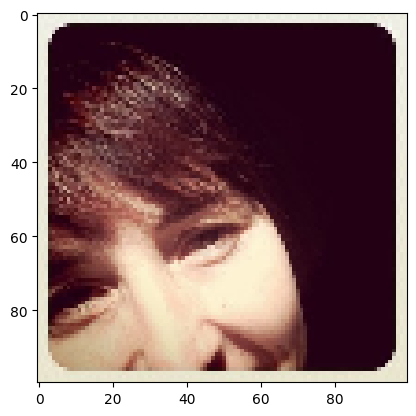

In [9]:
import matplotlib.pyplot as plt
plt.imshow(x_train_1[1])
plt.show()

In [10]:
# !pip install torchsummary
import torch
import torch.nn as nn
from torchvision import transforms, models, datasets
import torchsummary as summary
from torch.utils.data import DataLoader, TensorDataset
device= 'cuda' if torch.cuda.is_available() else 'cpu'
torch.backends.cudnn.benchmark = True # GPU 의 성능을 조금 더 끌어올립니다.

In [ ]:
x_train_1=torch.tensor(x_train_1).float()/255
x_train=x_train_1.permute(0,3,1,2).to(device)
y_train=torch.tensor(y_train_1).unsqueeze(1).float().to(device)
x_test_1=torch.tensor(x_test_1).float()/255.
x_test=x_test_1.permute(0,3,1,2).to(device)
y_test=torch.tensor(y_test_1).unsqueeze(1).float().to(device)


print(x_train.size(), y_train.shape)
print(x_test.shape, y_test.shape)
#print(y_test)

# | 프레임워크         | 입력 형태|
# | ---------------- | ------- |
# | TensorFlow/Keras | N,H,W,C |
# | PyTorch          | N,C,H,W |

torch.Size([1534, 3, 100, 100]) torch.Size([1534, 1])
torch.Size([171, 3, 100, 100]) torch.Size([171, 1])


In [12]:
train=TensorDataset(x_train,y_train)
test=TensorDataset(x_test, y_test)
train_dl=DataLoader(train, batch_size=32, shuffle=True)
test_dl=DataLoader(test, batch_size=len(test))

In [13]:
def conv_layer(ni, no, kernel_size):
    return nn.Sequential(nn.Conv2d(ni,no,kernel_size),
                         nn.SiLU(),  # SiLU(x)=x⋅σ(x),σ(x) 는 sigmoid 함수,음수 영역도 부드럽게 유지
                         nn.BatchNorm2d(no),
                         nn.MaxPool2d(2))

# 활성화 함수(Activation Function) :
# | 함수    | 특징                     |
# | ------- | ------------------------ |
# | ReLU    | 음수는 0으로 잘라버림    |
# | SiLU    | 음수 영역도 부드럽게 유지|
# | GELU    | Transformer에서 많이 사용|
# | Sigmoid | 출력 0~1                 |

In [14]:
def get_model():
    model=nn.Sequential(conv_layer(3,32,3),
                  conv_layer(32,64,3),
                  conv_layer(64,128,3),
                  conv_layer(128,256,3),
                  nn.AdaptiveAvgPool2d((1, 1)), # Ensure output is 1x1 before flattening.
                  nn.Flatten(),
                  nn.Linear(256,100),
                  nn.SiLU(),
                  nn.Linear(100,1),
                  nn.Sigmoid()
                  ).to(device)
    loss_fn=nn.BCELoss()
    optimizer=torch.optim.AdamW(model.parameters(),lr=1e-4)
    return model, loss_fn, optimizer


In [15]:
model, loss_fn, optimizer=get_model()
from torchsummary import summary
summary(model, input_size=(3,100,100),batch_size=10)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [10, 32, 98, 98]             896
              SiLU-2           [10, 32, 98, 98]               0
       BatchNorm2d-3           [10, 32, 98, 98]              64
         MaxPool2d-4           [10, 32, 49, 49]               0
            Conv2d-5           [10, 64, 47, 47]          18,496
              SiLU-6           [10, 64, 47, 47]               0
       BatchNorm2d-7           [10, 64, 47, 47]             128
         MaxPool2d-8           [10, 64, 23, 23]               0
            Conv2d-9          [10, 128, 21, 21]          73,856
             SiLU-10          [10, 128, 21, 21]               0
      BatchNorm2d-11          [10, 128, 21, 21]             256
        MaxPool2d-12          [10, 128, 10, 10]               0
           Conv2d-13            [10, 256, 8, 8]         295,168
             SiLU-14            [10, 25

In [16]:
def train_batch(x,y,model,opt,loss_fn):
    model.train()
    prediction=model(x)
    batch_loss=loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

In [17]:
@torch.no_grad()  # 자동 미분 비활성화 : gradient 계산 안함,메모리 절약,속도 증가
def accuracy(x,y, model):
    model.eval()
    prediction=model(x)
    is_correct=(prediction>0.5)==y
    return is_correct.cpu().numpy().tolist()

In [18]:
@torch.no_grad()
def val_loss(x,y, model):
    model.eval()
    prediction=model(x)
    val_loss =loss_fn(prediction,y)
    return val_loss.item()

In [19]:
# Colab : 약 16초 소요
import numpy as np
train_losses, train_accuracies =[], []
val_losses, val_accuracies=[],[]
for epoch in range(20):
    train_epoch_losses, train_epoch_accuracies =[], []
    val_epoch_accuracies=[]
    for ix, batch in enumerate(train_dl):
        x,y=batch
        batch_loss =train_batch(x,y,model,optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss=np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(train_dl):
        x, y=batch
        is_correct=accuracy(x,y,model)
        train_epoch_accuracies.extend(is_correct)#list of lists를 하나의 list로 풀어서 저장
    train_epoch_accuracy=np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(test_dl):
        x,y=batch
        val_is_correct=accuracy(x,y,model)
        val_epoch_accuracies.extend(val_is_correct)
    val_epoch_accuracy=np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_accuracies.append(val_epoch_accuracy)

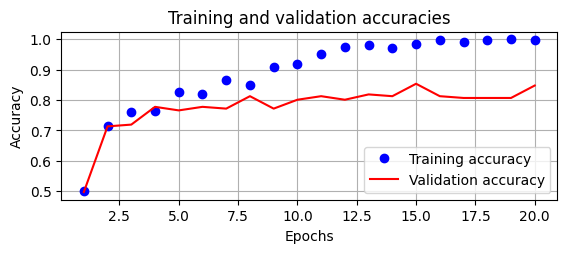

In [20]:
epochs = np.arange(20)+1
import matplotlib.pyplot as plt
%matplotlib inline
plt.subplot(211)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.title('Training and validation accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid('off')
plt.show()

In [21]:
print(train_losses)

[np.float64(0.6709363162517548), np.float64(0.6025479485591253), np.float64(0.5377348860104879), np.float64(0.4822026478747527), np.float64(0.45408012221256894), np.float64(0.4103467719008525), np.float64(0.37622249002257985), np.float64(0.3377901191512744), np.float64(0.2915720893070102), np.float64(0.2769462959840894), np.float64(0.235267274081707), np.float64(0.1813183253010114), np.float64(0.15661546494811773), np.float64(0.13041666522622108), np.float64(0.10502173604133229), np.float64(0.07901277028334637), np.float64(0.06717568934739877), np.float64(0.04980264111266782), np.float64(0.03717038407921791), np.float64(0.037211912722947695)]


In [22]:
x4=[]
y4=[]
for i in range(len(xx)):
    img2=cv2.resize(xx[i],(224,224))
    x4.append(img2)
    img_label=np.where(yy[i]=='male',1,0)
    y4.append(img_label)
xx4=np.array(x4)
print(xx4.shape)
yy4=np.array(y4)
print(yy4.shape)

from sklearn.model_selection import train_test_split
xx_train,xx_test,yy_train,yy_test=train_test_split(xx4, yy4,test_size=0.1,random_state=1, stratify=yy4)

print(xx_train.shape,xx_test.shape,yy_train.shape,yy_test.shape)

(1705, 224, 224, 3)
(1705,)
(1534, 224, 224, 3) (171, 224, 224, 3) (1534,) (171,)


In [23]:
xx_train=torch.tensor(xx_train).float()/255
xx_train=xx_train.permute(0,3,1,2).to(device)
yy_train=torch.tensor(yy_train).unsqueeze(1).float().to(device)
xx_test=torch.tensor(xx_test).float()/255.
xx_test=xx_test.permute(0,3,1,2).to(device)
yy_test=torch.tensor(yy_test).unsqueeze(1).float().to(device)


print(xx_train.size(), yy_train.shape)
print(xx_test.shape, yy_test.shape)

torch.Size([1534, 3, 224, 224]) torch.Size([1534, 1])
torch.Size([171, 3, 224, 224]) torch.Size([171, 1])


In [24]:
train_xx=TensorDataset(xx_train,yy_train)
test_xx=TensorDataset(xx_test, yy_test)
train_xxdl=DataLoader(train_xx, batch_size=32, shuffle=True)
test_xxdl=DataLoader(test_xx, batch_size=len(test))

In [25]:
# Colab : 약 28초 소요
import numpy as np
train_losses, train_accuracies =[], []
val_losses, val_accuracies=[],[]
for epoch in range(20):
    train_epoch_losses, train_epoch_accuracies =[], []
    val_epoch_accuracies=[]
    for ix, batch in enumerate(train_xxdl):
        x,y=batch
        batch_loss =train_batch(x,y,model,optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss=np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(train_xxdl):
        x, y=batch
        is_correct=accuracy(x,y,model)
        train_epoch_accuracies.extend(is_correct)#list of lists를 하나의 list로 풀어서 저장
    train_epoch_accuracy=np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(test_xxdl):
        x,y=batch
        val_is_correct=accuracy(x,y,model)
        val_epoch_accuracies.extend(val_is_correct)
    val_epoch_accuracy=np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_accuracies.append(val_epoch_accuracy)

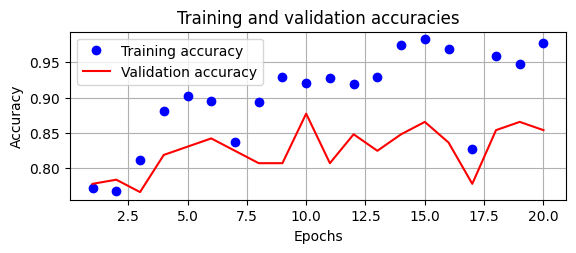

In [26]:
epochs = np.arange(20)+1
import matplotlib.pyplot as plt
%matplotlib inline
plt.subplot(211)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.title('Training and validation accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid('off')
plt.show()

In [27]:
model_vgg = models.vgg16(pretrained=True).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 229MB/s]


In [28]:
summary(model_vgg, input_size=(3,224,224), batch_size=20)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [20, 64, 224, 224]           1,792
              ReLU-2         [20, 64, 224, 224]               0
            Conv2d-3         [20, 64, 224, 224]          36,928
              ReLU-4         [20, 64, 224, 224]               0
         MaxPool2d-5         [20, 64, 112, 112]               0
            Conv2d-6        [20, 128, 112, 112]          73,856
              ReLU-7        [20, 128, 112, 112]               0
            Conv2d-8        [20, 128, 112, 112]         147,584
              ReLU-9        [20, 128, 112, 112]               0
        MaxPool2d-10          [20, 128, 56, 56]               0
           Conv2d-11          [20, 256, 56, 56]         295,168
             ReLU-12          [20, 256, 56, 56]               0
           Conv2d-13          [20, 256, 56, 56]         590,080
             ReLU-14          [20, 256,

In [29]:
print(model_vgg)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [30]:
def get_vgg():
    model=models.vgg16(pretrained=True)
    for param in model.parameters():
        param.requires_grad =False
    model.classifier[6]=nn.Sequential(nn.Linear(4096,1),
                                      nn.Sigmoid()
                                     )
    loss_fn=nn.BCELoss()
    optimizer=torch.optim.AdamW(model.parameters(), lr=1e-3)
    return model.to(device), loss_fn, optimizer

In [31]:
model_vgg, loss_fn, optimizer = get_vgg()

In [32]:
# Colab : 약 1분 소요
import numpy as np
train_losses, train_accuracies =[], []
val_losses, val_accuracies=[],[]
for epoch in range(20):
    train_epoch_losses, train_epoch_accuracies =[], []
    val_epoch_accuracies=[]
    for ix, batch in enumerate(train_xxdl):
        x,y=batch
        batch_loss =train_batch(x,y,model_vgg,optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss=np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(train_xxdl):
        x, y=batch
        is_correct=accuracy(x,y,model_vgg)
        train_epoch_accuracies.extend(is_correct)#list of lists를 하나의 list로 풀어서 저장
    train_epoch_accuracy=np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(test_xxdl):
        x,y=batch
        val_is_correct=accuracy(x,y,model_vgg)
        val_epoch_accuracies.extend(val_is_correct)
    val_epoch_accuracy=np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_accuracies.append(val_epoch_accuracy)

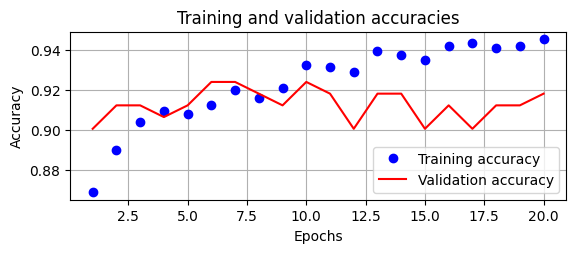

In [33]:
epochs = np.arange(20)+1
import matplotlib.pyplot as plt
%matplotlib inline
plt.subplot(211)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.title('Training and validation accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid('off')
plt.show()